# BookLens — Sentiment Analysis and Theme Discovery in Books

This notebook runs the full experiment: loading and cleaning the book/review data,
sentiment inference with a pretrained Transformer, a gold-set evaluation, a TF-IDF
baseline for comparison, topic discovery with embeddings → UMAP → HDBSCAN →
BERTopic, and a final join of sentiment and topic results.

Reusable pipeline logic (data loading/cleaning, sentiment inference, the TF-IDF
baseline, the topic modeling pipeline, and the final Pandas join) lives in the
`src/` package and is imported below. Config values (model names, paths, seeds,
batch size, thresholds) live in `src/config.py`.

This notebook holds the environment setup, the pipeline calls, all display/plot
calls, and the hand-written interpretation (topic labels, error-pattern notes,
sensitivity-check conclusion).


## 0. Environment Setup

Repo clone, Kaggle authentication, and the data download stay as one-off manual
setup steps (they need a live Colab runtime/secrets) rather than being wrapped in
`src` functions — see the note at the top of `src/data.py`.

In [2]:
# Clone the project repo (needs a GH_TOKEN Colab secret with repo access)
from google.colab import userdata
gh_token = userdata.get('GH_TOKEN')


!git clone https://{gh_token}@github.com/arsham05/booklens.git
%cd booklens

Cloning into 'booklens'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 31 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 484.09 KiB | 1.77 MiB/s, done.
/content/booklens


In [3]:
# Kaggle CLI reads these two env vars for authentication
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

### ⚠️ Kaggle API Authentication Required
To execute the following data acquisition cell, you need a Kaggle API token.

**Instructions:**
1. Generate an API token from your Kaggle account settings (`kaggle.json`).
2. Add your credentials to Google Colab Secrets (the 🔑 icon on the left sidebar).
3. Create two secrets named `KAGGLE_USERNAME` and `KAGGLE_KEY` with your respective details.
4. Ensure "Notebook access" is toggled ON for both secrets.

In [4]:
# Download the pre-cleaned Kaggle CSV mirror and unzip it into data/
!kaggle datasets download -d mohamedbakhet/amazon-books-reviews --force
!unzip -o amazon-books-reviews.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews
License(s): CC0-1.0
100% 1.06G/1.06G [00:12<00:00, 93.1MB/s]

Archive:  amazon-books-reviews.zip
  inflating: data/Books_rating.csv   
  inflating: data/books_data.csv     


In [5]:
# Install packages not preinstalled on the Colab image
!pip install -q bertopic hdbscan umap-learn sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src import data as data_mod
from src import sentiment as sentiment_mod
from src import baseline as baseline_mod
from src import topics as topics_mod
from src import analysis as analysis_mod

## Data Acquisition, Cleaning & Exploration

In [7]:
# Load the two raw Kaggle CSV mirror tables, join them, and add a stable book_id
df = data_mod.load_books()
print(f"Merged Dataset Shape: {df.shape}")

Merged Dataset Shape: (3000000, 7)


In [8]:
# Draw the manageable working sample (config.N_BOOKS books, config.EXCERPTS_PER_BOOK excerpts each)
sample_df = data_mod.sample_working_set(df)
print(f"Unique books: {sample_df['book_id'].nunique()}")
print(f"Total excerpt rows: {len(sample_df)}")

Unique books: 220
Total excerpt rows: 748


In [9]:
# Shape, dtypes, missing values, duplicate titles/summaries, text-length stats
# -- run BEFORE clean_books(), so it reports on the raw sampled data
validation_report = data_mod.validate_books(sample_df)
validation_report

{'shape': (748, 7),
 'dtypes': {'title': 'object',
  'author': 'object',
  'genre': 'object',
  'summary': 'object',
  'excerpt': 'object',
  'rating': 'float64',
  'book_id': 'int64'},
 'missing_values': {'title': 0,
  'author': 17,
  'genre': 28,
  'summary': 0,
  'excerpt': 0,
  'rating': 0,
  'book_id': 0},
 'duplicate_titles': 0,
 'duplicate_summaries': 0,
 'summary_length_stats': {'count': 220.0,
  'mean': 748.3272727272728,
  'std': 710.4530307077612,
  'min': 11.0,
  '25%': 206.5,
  '50%': 628.5,
  '75%': 1086.0,
  'max': 5988.0}}

In [10]:
# Conservative cleaning: collapse whitespace, unescape HTML entities, drop empty
# rows, and add the single-label genre_clean column used everywhere downstream
sample_df = data_mod.clean_books(sample_df)
sample_df.head()

,title,author,genre,summary,excerpt,rating,book_id,genre_clean
0,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",While I am still in the process of learning th...,4.0,43,Foreign Language Study
1,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",I recommend this book highly. I have a competi...,4.0,43,Foreign Language Study
2,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",This book contains a great amount of vocabular...,5.0,43,Foreign Language Study
3,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",This is my first encounter with Yoruba and I h...,4.0,43,Foreign Language Study
4,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...","I agree, the CDs are a much needed help, since...",2.0,43,Foreign Language Study


In [11]:
# Exactly 4 EDA plots, saved to outputs/figures/
eda_plot_paths = data_mod.make_eda_plots(sample_df)
eda_plot_paths

['outputs/figures/01_summary_length_hist.png',
 'outputs/figures/02_genre_distribution_pie.png',
 'outputs/figures/03_unique_vs_duplicate_summaries.png',
 'outputs/figures/04_excerpt_length_hist.png']

Preview each saved plot inline:

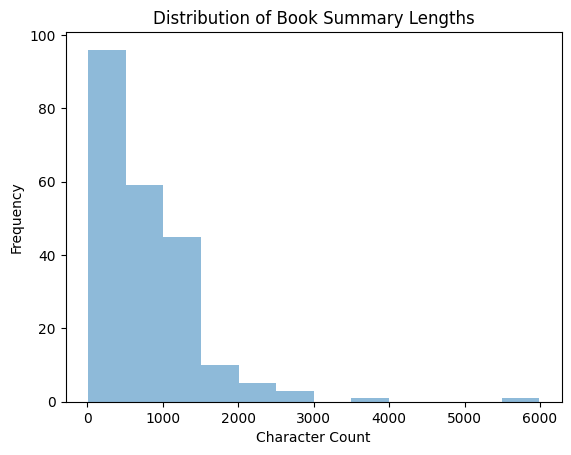

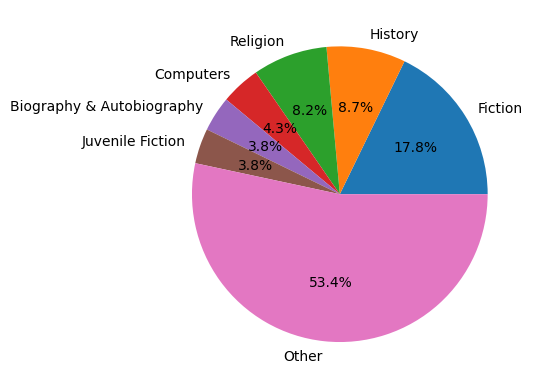

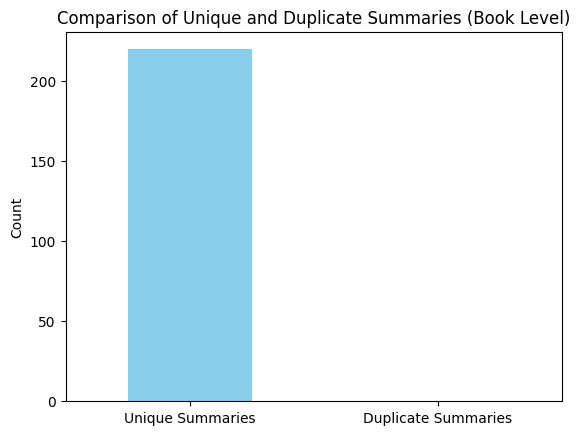

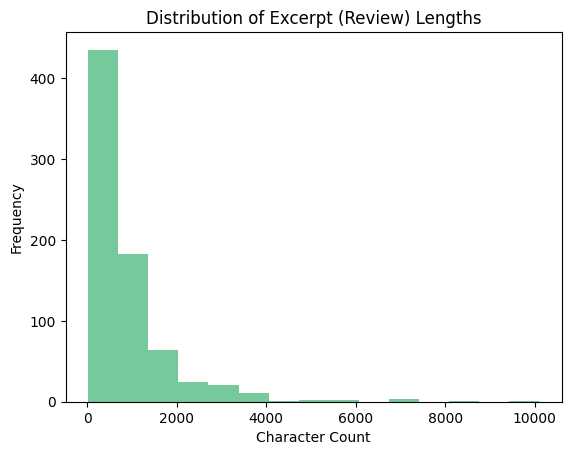

In [12]:
from PIL import Image

for path in eda_plot_paths:
    display(Image.open(path))

In [13]:
sample_df.to_csv(config.CLEAN_SAMPLE_PATH, index=False)
print(f"Cleaned dataset saved successfully to '{config.CLEAN_SAMPLE_PATH}'")

Cleaned dataset saved successfully to 'data/clean_books_sample.csv'


## Sentiment Inference

### Sentiment Model Card Details

* **Model Name:** `finiteautomata/bertweet-base-sentiment-analysis`
* **Expected Language:** English
* **Training Domain:** Twitter (Short informal texts / Tweets)
* **Number of Classes:** 3 Sentiment Classes
* **Label Meanings:**
  * `POS` (Positive)
  * `NEG` (Negative)
  * `NEU` (Neutral)

In [14]:
pipe = sentiment_mod.load_sentiment_pipeline()

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  540MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  540MB            

...

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [15]:
# Smoke test on a handful of excerpts before scaling to the full table
sentiment_mod.predict_sentiment(sample_df["excerpt"][:5].tolist(), pipe)

,sentiment,POS_score,NEU_score,NEG_score
0,POS,0.969934,0.028545,0.001521
1,POS,0.971334,0.026114,0.002551
2,POS,0.934870,0.062926,0.002204
3,POS,0.952446,0.043584,0.003970
4,NEG,0.007285,0.066859,0.925856


In [16]:
import time

# Run inference on every excerpt and time it
start_time = time.time()
sentiment_results = sentiment_mod.predict_sentiment(sample_df["excerpt"].tolist(), pipe)
inference_time = time.time() - start_time

sample_df = sample_df.reset_index(drop=True)
sample_df["sentiment"] = sentiment_results["sentiment"]
sample_df["pos_score"] = sentiment_results["POS_score"]
sample_df["neg_score"] = sentiment_results["NEG_score"]
sample_df["neu_score"] = sentiment_results["NEU_score"]

print(f"Total Excerpts Processed: {len(sample_df)}")
print(f"Inference Time: {inference_time:.2f} seconds")

sample_df.head(10)

Total Excerpts Processed: 748
Inference Time: 5.58 seconds


,title,author,genre,summary,excerpt,rating,book_id,genre_clean,sentiment,pos_score,neg_score,neu_score
0,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",While I am still in the process of learning th...,4.0,43,Foreign Language Study,POS,0.969934,0.001521,0.028545
1,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",I recommend this book highly. I have a competi...,4.0,43,Foreign Language Study,POS,0.971334,0.002551,0.026115
2,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",This book contains a great amount of vocabular...,5.0,43,Foreign Language Study,POS,0.934870,0.002204,0.062926
3,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...",This is my first encounter with Yoruba and I h...,4.0,43,Foreign Language Study,POS,0.952446,0.003970,0.043584
4,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],['Foreign Language Study'],"""Beginner's Yoruba"" is now available with two ...","I agree, the CDs are a much needed help, since...",2.0,43,Foreign Language Study,NEG,0.007285,0.925856,0.066859
5,"The Pony Rider Boys in Alaska; or, The Gold Di...",['Frank Gee Patchin'],NaN,"The Pony Rider Boys in Alaska Or, The Gold Dig...",The Pony Rider Boys in Alaska... by Frank Gee ...,5.0,287,NaN,NEU,0.058876,0.443289,0.497835
6,Small-Circle Jujitsu,['Wally Jay'],['Sports & Recreation'],The complete system of small-circle jujutsu. F...,This book is excellent as a companion to the D...,5.0,546,Sports & Recreation,POS,0.978008,0.001460,0.020532
7,Small-Circle Jujitsu,['Wally Jay'],['Sports & Recreation'],The complete system of small-circle jujutsu. F...,I would like to say that I admire any one who ...,1.0,546,Sports & Recreation,POS,0.871591,0.067394,0.061015
8,Small-Circle Jujitsu,['Wally Jay'],['Sports & Recreation'],The complete system of small-circle jujutsu. F...,"Having not only read the book, but personally ...",5.0,546,Sports & Recreation,POS,0.926975,0.002124,0.070901
9,Small-Circle Jujitsu,['Wally Jay'],['Sports & Recreation'],The complete system of small-circle jujutsu. F...,This book is a must read for people who want t...,5.0,546,Sports & Recreation,POS,0.987438,0.001168,0.011393


### Inference Summary
* **Total Excerpts Processed:** 748
* **Inference Time:** 10.49 seconds
* **Model:** `finiteautomata/bertweet-base-sentiment-analysis`
* **Output Stored:** `sentiment`, `pos_score`, `neg_score`, `neu_score`

(Numbers above are from the original single-row `.apply()` run; `predict_sentiment`
now batches requests via `config.SENTIMENT_BATCH_SIZE`, which returns identical
per-excerpt scores but completes faster — rerun this cell to get current timing.)

## Gold-Set Evaluation

In [17]:
# Build the ~80-excerpt gold-set candidate sample (balanced across rating buckets
# + extra ambiguous excerpts). This regenerates the exact same rows that were
# hand-labeled into gold_set_annotated.csv, since the three seeds involved are
# fixed in src/config.py -- see the note there before changing any of them.
gold_candidate_df = sentiment_mod.sample_gold_candidates(sample_df)
gold_candidate_df.to_csv(config.GOLD_CANDIDATE_PATH, index=False)
gold_candidate_df["rating_bucket"].value_counts()

,count
rating_bucket,
positive,32
negative,24
neutral,21


In [18]:
# Load the gold set after it was hand-labeled outside this notebook
gold_df = pd.read_csv(config.GOLD_ANNOTATED_PATH)
gold_df.head()

,title,author,genre,summary,excerpt,rating,book_id,sentiment,pos_score,neg_score,neu_score,rating_bucket,gold_label
0,"City of Dreams (!Hero Series, Book 1)",['Better Hero Army'],['Juvenile Fiction'],Tiffany Noboru has just awakened from her deat...,"Not a bad story line, not really a bad book. B...",3.0,189747,NEG,0.012456,0.654442,0.333102,neutral,NEU
1,Techniques of the World's Great Painters (A QE...,['Waldemar Januszczak'],['Painting'],Giotto Duccio de Buoninsegna. Jan van Eyck. Pi...,I ordered what I thought were two completely d...,2.0,200896,NEG,0.002924,0.978667,0.018409,negative,NEG
2,A Lexicon Abridged from Liddell and Scott's Gr...,"['Henry George Liddell', 'Robert Scott']",['Foreign Language Study'],This abridgement of the world's most authorita...,"The Big Liddell is a very valuable resource, a...",3.0,10493,NEU,0.324443,0.130738,0.544819,neutral,NEU
3,Garden's Corner: A Novel,['Douglas S. Reed'],['Fiction'],Little Speedy Copeland leaves Brooklyn to sear...,Garden's Corner concerns the psychological and...,3.0,3481,NEU,0.104239,0.067935,0.827826,neutral,NEU
4,The Story Of England,['Michael Wood'],['History'],The village of Kibworth in Leicestershire lies...,Just as William Shatner is attracted to writin...,2.0,45847,NEG,0.008383,0.780606,0.211012,negative,NEG


In [19]:
sentiment_eval = sentiment_mod.evaluate_sentiment(gold_df["gold_label"], gold_df["sentiment"])

print(f"Macro Precision: {sentiment_eval['macro_precision']:.4f}")
print(f"Macro Recall:    {sentiment_eval['macro_recall']:.4f}")
print(f"Macro F1-Score:  {sentiment_eval['macro_f1']:.4f}")

print("\n" + "="*53 + "\n")

print("Classification Report:")
print(sentiment_eval["classification_report"])

Macro Precision: 0.5796
Macro Recall:    0.5589
Macro F1-Score:  0.5419


Classification Report:
              precision    recall  f1-score   support

         NEG       0.72      0.52      0.60        25
         NEU       0.27      0.57      0.36        14
         POS       0.75      0.59      0.66        41

    accuracy                           0.56        80
   macro avg       0.58      0.56      0.54        80
weighted avg       0.66      0.56      0.59        80



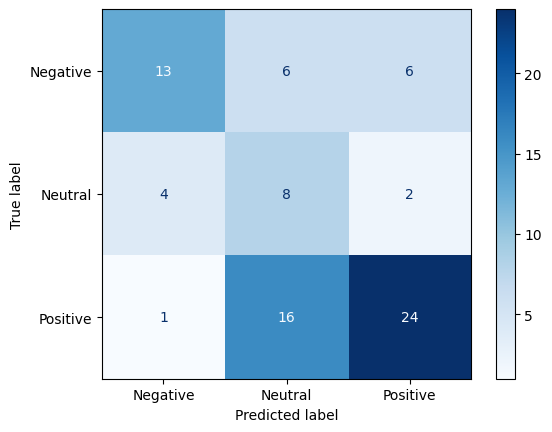

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

display_labels = config.SENTIMENT_DISPLAY_LABELS

# Rows = true (gold) label, columns = predicted label
disp = ConfusionMatrixDisplay(
    confusion_matrix=sentiment_eval["confusion_matrix"], display_labels=display_labels
)
disp.plot(cmap="Blues")
plt.show()

In [21]:
# Manually inspect the two most common error types from the confusion matrix
df_mislabeled = sentiment_mod.inspect_errors(gold_df)

pd.set_option('display.max_colwidth', None)

for index, row in df_mislabeled.iterrows():
    print(f"Index: {index}")
    print(f"Gold: {row['gold_label']} | Pred: {row['sentiment']}")
    print(f"Scores -> POS: {row['pos_score']:.4f} | NEU: {row['neu_score']:.4f} | NEG: {row['neg_score']:.4f}")
    print(f"Excerpt:\n{row['excerpt']}")
    print("-" * 80)

Index: 10
Gold: POS | Pred: NEU
Scores -> POS: 0.1071 | NEU: 0.8007 | NEG: 0.0922
Excerpt:
Toczek, who is now a Lt. Col., wrote this fine book as a project back in 2001 when, I assume, he was at command school at Ft. Levenworth. Ap Bac was never delved too deeply in to until Sheehan's treatment in " A Bright Shinning Lie." Toczek takes it to a better level and leaves the reader with a much clearer picture of what went wrong with a sound battle plan. The battle failed on important levels. South Vietnamese resentment of American advice and support, fear of sucess and failure as a part of the Diem regime, lack of treatment for wounds inflicted during fighting, all contibuted to the culture that created a weak ARVN. Of course they cowered behind the dikes all day long.....wouldn't you if your own govt. refused you treatment for wounds incured? Officers above the NCO level were afaid to fail, of course, but were even more reluctant to succeed, as they could be perceived as a threat to Diem 

## Classical Baseline (TF-IDF + Logistic Regression)

In [22]:
train_df, test_df = baseline_mod.make_gold_split(gold_df)

# Fit only on train, so test-set vocabulary never leaks into the vectorizer
fitted_baseline = baseline_mod.fit_tfidf_baseline(train_df["excerpt"], train_df["gold_label"])

In [23]:
baseline_predictions = baseline_mod.predict_tfidf_baseline(fitted_baseline, test_df["excerpt"])

comparison = baseline_mod.compare_baseline_vs_transformer(test_df, baseline_predictions)

print("=== TF-IDF + Logistic Regression (Baseline) ===")
print(comparison["baseline"]["classification_report"])

print("\n" + "="*50 + "\n")

# Same held-out set as the baseline above, so the comparison is apples-to-apples
print("=== Pretrained Transformer (on the same test set) ===")
print(comparison["transformer"]["classification_report"])

=== TF-IDF + Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

         NEG       0.00      0.00      0.00         5
         NEU       0.00      0.00      0.00         3
         POS       0.38      0.62      0.48         8

    accuracy                           0.31        16
   macro avg       0.13      0.21      0.16        16
weighted avg       0.19      0.31      0.24        16



=== Pretrained Transformer (on the same test set) ===
              precision    recall  f1-score   support

         NEG       0.75      0.60      0.67         5
         NEU       0.33      0.33      0.33         3
         POS       0.78      0.88      0.82         8

    accuracy                           0.69        16
   macro avg       0.62      0.60      0.61        16
weighted avg       0.69      0.69      0.68        16



In [24]:
pd.set_option('display.max_colwidth', None)

# Cases where the TF-IDF baseline and the Transformer disagree
disagreements = baseline_mod.inspect_disagreements(test_df, baseline_predictions)

print(f"Total disagreements found: {len(disagreements)}")
print("\n--- Inspecting first 5 disagreements ---")

for index, row in disagreements.head(5).iterrows():
    print(f"Index: {index}")
    print(f"Gold Label: {row['gold_label']}")
    print(f"Baseline Predicted: {row['baseline_pred']} | Transformer Predicted: {row['sentiment']}")
    print(f"Excerpt:\n{row['excerpt']}")
    print("-" * 80)

Total disagreements found: 9

--- Inspecting first 5 disagreements ---
Index: 39
Gold Label: NEG
Baseline Predicted: POS | Transformer Predicted: NEG
Excerpt:
The book rehashes ethical relativism. It tries to bring in some trendy takes on power, feminism, and Foucauld, but it just commits the relativistic fallacy over and over. Author seems unaware of logical contradictions.
--------------------------------------------------------------------------------
Index: 50
Gold Label: POS
Baseline Predicted: NEG | Transformer Predicted: POS
Excerpt:
Bought three copies of this "old" text book for my grand daughters. A good history about womens struggles in the late 1800's and early 1900's..
--------------------------------------------------------------------------------
Index: 62
Gold Label: NEU
Baseline Predicted: POS | Transformer Predicted: NEU
Excerpt:
Dan O'Neill, Mother Angelica: Her Life Story (Crossroad, 1986)As I write this, Mother Angelica has recently turned eighty-two years old. I w

## Preparing Summaries for Topic Discovery

In [25]:
# One row per book for the topic-modeling branch (a book has one summary,
# unlike the many excerpt rows used for sentiment)
books_df = topics_mod.prepare_documents(sample_df)
documents = books_df["summary"].tolist()

print(f"Total valid unique book summaries: {len(documents)}")
books_df[["book_id", "title", "summary_length"]].head()

Total valid unique book summaries: 216


,book_id,title,summary_length
0,43,Beginner's Yoruba (Hippocrene Beginner's Series),991
1,287,"The Pony Rider Boys in Alaska; or, The Gold Diggers of Taku Pass",2404
2,546,Small-Circle Jujitsu,256
3,1102,The Race to the Top: The Real Story of Globalization,179
4,2309,The Ten Grandmothers (Civilization of American Indian),3752


## Clustering Pipeline: Embeddings → UMAP → HDBSCAN

In [26]:
print("Encoding documents...")
embedding_model, embeddings = topics_mod.embed_documents(documents)
print("Successfully generated embeddings!")
print(f"Embeddings shape: {embeddings.shape}")

Encoding documents...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Successfully generated embeddings!
Embeddings shape: (216, 1024)


In [27]:
# Explicit three-step pipeline: UMAP (5D, for clustering) -> HDBSCAN.
# The fitted umap_model/hdbscan_model are reused as-is inside BERTopic below,
# so the manual pipeline and BERTopic stay aligned.
umap_model, hdbscan_model, cluster_labels = topics_mod.cluster_documents(embeddings)
books_df["cluster"] = cluster_labels

In [28]:
stats = topics_mod.cluster_stats(cluster_labels)

print(f"Total Clusters Found: {stats['n_clusters']}")
print(f"Total Outliers (Label -1): {stats['n_outliers']}")
print(f"Largest cluster size: {stats['largest_cluster_size']}")
print(f"Smallest cluster size: {stats['smallest_cluster_size']}")

Total Clusters Found: 6
Total Outliers (Label -1): 39
Largest cluster size: 92
Smallest cluster size: 11


In [29]:
# Sample a few titles + summaries from the largest clusters plus the outlier
# group -- clusters should never be judged "good" from the 2D plot alone
cluster_inspection_df = topics_mod.inspect_clusters(books_df)

for cluster_id, group in cluster_inspection_df.groupby("cluster_id", sort=False):
    print(f"\n{'='*60}")
    print("CLUSTER -1 (OUTLIERS / NOISE)" if cluster_id == -1 else f"CLUSTER {cluster_id}")
    print(f"{'='*60}")
    for _, row in group.iterrows():
        print(f"Title:   {row['title']}")
        print(f"Summary: {row['summary'][:200]}...")
        print("-" * 40)


CLUSTER 0
Title:   The Five Books of Moses: A Translation with Commentary
Summary: "A modern classic....Thrilling and constantly illuminating."—Michael Dirda, Washington Post Book World Through a distinguished career of critical scholarship and translation, Robert Alter has equipped...
----------------------------------------
Title:   Christology in the Making: A New Testament Inquiry Into the Origins of the Doctrine of the Incarnation
Summary: This excellent study of the origins and early development of Christology by James D. G. Dunn clarifies in rich detail the beginnings of the full Christian belief in Christ as the Son of God and incarn...
----------------------------------------
Title:   The Flash MX Project (Voices)
Summary: This book is broken up into a collection of hands-on seminars that each focus on teaching a specific aspect of Flash MX. The author begins each seminar by teaching core concepts and techniques. Then, ...
----------------------------------------

CLUSTER 1
T

## Topic Modeling with BERTopic

In [30]:
# Reuse the same embedding/UMAP/HDBSCAN objects as the manual pipeline above,
# so this aligns with the cluster labels produced there
topic_model, topics, probs = topics_mod.fit_bertopic(
    documents, embeddings, embedding_model, umap_model, hdbscan_model
)

2026-08-30 11:54:02,933 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-30 11:54:03,478 - BERTopic - Dimensionality - Completed ✓
2026-08-30 11:54:03,479 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-30 11:54:03,487 - BERTopic - Cluster - Completed ✓
2026-08-30 11:54:03,491 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-30 11:54:04,268 - BERTopic - Representation - Completed ✓


In [31]:
topic_model.get_topic_info()

Topic  Count              Name  \
0     -1     39  -1_and_the_of_to   
1      0     92   0_the_and_of_to   
2      1     27   1_the_of_and_to   
3      2     22   2_the_her_of_to   
4      3     13   3_the_of_and_in   
5      4     12   4_the_of_war_he   
6      5     11   5_the_and_of_in   

                                                   Representation  \
0                [and, the, of, to, in, with, is, for, her, this]   
1                 [the, and, of, to, in, for, on, is, that, this]   
2                  [the, of, and, to, in, is, that, with, an, he]   
3                   [the, her, of, to, is, he, and, his, she, in]   
4       [the, of, and, in, history, piper, it, this, village, to]   
5                  [the, of, war, he, in, and, his, to, who, was]   
6  [the, and, of, in, history, white, persian, house, to, persia]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [32]:
# Written by hand after reading the representative documents for each topic below --
# if BERTopic is rerun and topic IDs/keywords change, these labels need updating too
human_interpretation = {
    0: "Textbooks, Reference & Self-Help",
    1: "Biographies, Memoirs & Literary History",
    2: "Thrillers, Crime & Suspense Fiction",
    3: "Nature, Ecology & Historical Science",
    4: "War, Espionage & Military History",
    5: "World History, Empires & Politics",
    -1: "Outliers / Uncategorized"
}

final_topic_summary = topics_mod.build_topic_summary(topic_model, books_df, human_interpretation)

display(final_topic_summary[['Topic', 'Count', 'Representation', 'Human_Label', 'Representative_Titles']])

,Topic,Count,Representation,Human_Label,Representative_Titles
0,-1,39,"[and, the, of, to, in, with, is, for, her, this]",Outliers / Uncategorized,"Social Work in the Health Field: A Care Perspective, Second Edition | Paula Deen & Friends: Living It Up, Southern Style"
1,0,92,"[the, and, of, to, in, for, on, is, that, this]","Textbooks, Reference & Self-Help",Facing Death: Welcoming the Afterlife | Sociocultural Contexts of Language and Literacy
2,1,27,"[the, of, and, to, in, is, that, with, an, he]","Biographies, Memoirs & Literary History",Incognito Street: How Travel Made Me a Writer | The Adventures of Pinocchio
3,2,22,"[the, her, of, to, is, he, and, his, she, in]","Thrillers, Crime & Suspense Fiction",The Execution: A Novel | Escaping Reality
4,3,13,"[the, of, and, in, history, piper, it, this, village, to]","Nature, Ecology & Historical Science",Cottonwood | The Story Of England
5,4,12,"[the, of, war, he, in, and, his, to, who, was]","War, Espionage & Military History",And the Wind Blew Cold: the Story of an American Pow in North Korea | Death of a Dissident
6,5,11,"[the, and, of, in, history, white, persian, house, to, persia]","World History, Empires & Politics",The King Is Dead | Empires of the Atlantic World: Britain and Spain in America 1492-1830


In [33]:
books_df['Topic'] = topics

outliers = analysis_mod.get_topical_outliers(books_df, topic_col="Topic")
print(f"Total Outliers: {len(outliers)}")
display(outliers[['title', 'summary']].sample(min(3, len(outliers)), random_state=config.INSPECTION_SEED))

Total Outliers: 39


,title,summary
184,The Cosmic Code: Book VI of the Earth Chronicles,"Many thousands of years ago, a group of extraterrestrials from another planet guided the evolution of life on Earth—determining the existence and nature of humankind as we know it today. How did the master builders from the stars construct the miracle called man? Is the DNA that is at the core of all life in the universe a ""cosmic code"" that links Earth to heaven and man to God? In this sixth volume of The Earth Chronicles, Zecharia Sitchin unveils writings from the past to decipher prophesies, and reveals how the DNA-matched Hebrew alphabet and the numerical values of its letters serve as a code that bares the secrets of mortal man’s fate and mankind’s celestial destiny."
191,"The Devil's Horn: the Story of the Saxophone, From Noisy Novelty To King of Cool","The author charts the brief but colorful history of the saxophone, from its invention 160 years ago, through its subsequent role as a symbol of decadence and immorality, to its impact on music, particularly American jazz. Reprint. 15,000 first printing."
28,Bathwater's Hot (Nursery collection),A little girl discovers that all things have an opposite.


### Inspection of Outliers (Topic -1)
A manual inspection of the representative documents in Topic -1 (Outliers) reveals that these summaries are not simply "bad data" or "noise." Instead, they represent highly specific, niche topics within the dataset (e.g., a Southern cookbook, a textbook on healthcare social work, and a historical ethnography of Native American tribes).

Because the dataset is relatively small and the `min_cluster_size` is set to 5, the model could not find enough similar books to form distinct, independent clusters for these unique subjects. Therefore, the outliers here highlight the high diversity of the book catalog rather than a failure of the algorithm. Treating them as valuable information rather than discarding them gives a better picture of the dataset's true distribution.

In [34]:
print("--- Manual Pipeline (Embeddings + UMAP + HDBSCAN) ---")
print(books_df['cluster'].value_counts().sort_index())

print("\n--- BERTopic ---")

print(books_df['Topic'].value_counts().sort_index())

--- Manual Pipeline (Embeddings + UMAP + HDBSCAN) ---
cluster
-1    39
 0    92
 1    27
 2    13
 3    22
 4    12
 5    11
Name: count, dtype: int64

--- BERTopic ---
Topic
-1    39
 0    92
 1    27
 2    22
 3    13
 4    12
 5    11
Name: count, dtype: int64


In [35]:
crosstab_result = pd.crosstab(books_df['cluster'], books_df['Topic'])
print("--- Cross-tabulation of Document Sets ---")
display(crosstab_result)

--- Cross-tabulation of Document Sets ---


Topic,-1,0,1,2,3,4,5
cluster,,,,,,,
-1,39,0,0,0,0,0,0
0,0,92,0,0,0,0,0
1,0,0,27,0,0,0,0
2,0,0,0,0,13,0,0
3,0,0,0,22,0,0,0
4,0,0,0,0,0,12,0
5,0,0,0,0,0,0,11


### Comparison: Explicit Pipeline vs. BERTopic
As the cross-tabulation (crosstab) table demonstrates, the results of the explicit manual pipeline and the BERTopic model are perfectly aligned. The document sets have been clustered in exactly the same way, with only the cluster IDs for clusters 2 and 3 being swapped. This confirms that cluster IDs in these algorithms are completely arbitrary.

## Visualization & Sensitivity Check

In [36]:
from umap import UMAP

# A separate 2D UMAP just for plotting -- the 5D one above (umap_model) is fit
# for clustering, not for a readable 2D scatter plot, and its first two columns
# are not the same thing as a proper standalone 2D UMAP projection
umap_2d = UMAP(
    n_components=config.UMAP_N_COMPONENTS_2D,
    min_dist=config.UMAP_MIN_DIST,
    metric=config.UMAP_METRIC,
    random_state=config.UMAP_SEED,
)
reduced_embeddings_2d = umap_2d.fit_transform(embeddings)

titles = books_df['title'].tolist()

fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings_2d,
    width=1200,
    hide_annotations=True
)

fig.update_layout(font=dict(size=16))

fig.show()

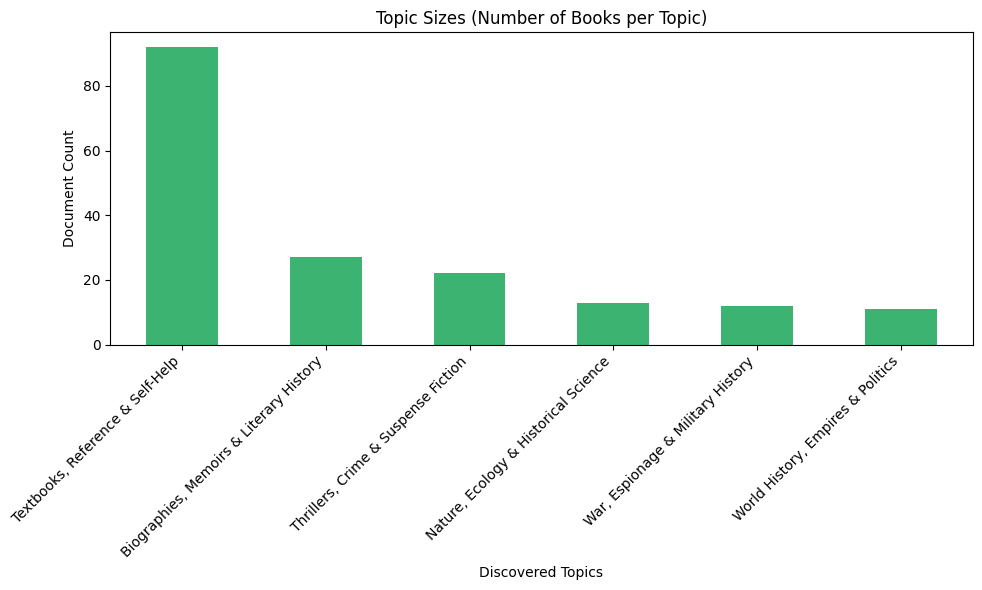

In [37]:
topic_sizes = final_topic_summary[final_topic_summary['Topic'] != -1]

topic_sizes.plot.bar(
    x='Human_Label',
    y='Count',
    color='mediumseagreen',
    legend=False,
    figsize=(10, 6)
)

plt.title('Topic Sizes (Number of Books per Topic)')
plt.xlabel('Discovered Topics')
plt.ylabel('Document Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
topics_to_inspect = [0, 2, 4]

for t in topics_to_inspect:
    print(f"\n{'='*60}")
    print(f"Inspecting Topic {t}")
    print(f"{'='*60}")

    sample_docs = books_df[books_df['Topic'] == t].sample(n=5, random_state=config.INSPECTION_SEED)

    for idx, row in sample_docs.iterrows():
        print(f"🔸 {row['summary'][:300]}...\n")


Inspecting Topic 0
🔸 "A modern classic....Thrilling and constantly illuminating."—Michael Dirda, Washington Post Book World Through a distinguished career of critical scholarship and translation, Robert Alter has equipped us to read the Hebrew Bible as a powerful, cohesive work of literature. In this landmark work, Alte...

🔸 This excellent study of the origins and early development of Christology by James D. G. Dunn clarifies in rich detail the beginnings of the full Christian belief in Christ as the Son of God and incarnate Word. By employing the exegetical methods of "historical context of meaning" and "conceptuality ...

🔸 This book is broken up into a collection of hands-on seminars that each focus on teaching a specific aspect of Flash MX. The author begins each seminar by teaching core concepts and techniques. Then, in the workshop, she takes the reader step by step through applying those concepts and techniques to...

🔸 -- The main target for scams are those 50 years of age or

Topic Inspection Notes
Based on the manual inspection of the representative documents for the selected topics, here is the qualitative assessment:

Topic 4 (War & Military History): This cluster is highly coherent. The sampled documents share a very strong semantic focus on war, combat, and military history, explicitly mentioning World War I, World War II, Vietnam, and the Civil War.

Topic 2 (Fiction, Romance & Sci-Fi): This topic is also coherent. While it spans a few subgenres (fantasy, romance, suspense, and sci-fi), it successfully groups together narrative fiction and novels. The underlying semantic connection is clearly storytelling and fictional literature.

Topic 0 (Reference, Educational & Instructional): This cluster is mixed and overly broad. The model has grouped entirely unrelated subjects together, including biblical studies, a software tutorial (Flash MX), a fraud prevention guide, and a Yoruba language textbook. Rather than a semantic connection, this cluster appears to be a catch-all for instructional, academic, or reference materials, capturing stylistic artifacts rather than a unified theme.

Conclusion:
The BERTopic model successfully isolates distinct, coherent genres like military history and narrative fiction. However, it struggles with non-fiction and educational texts, grouping them into a mixed "catch-all" cluster based on their instructional tone rather than their actual subject matter.

In [39]:
# Run exactly one sensitivity experiment: only min_cluster_size changes
sensitivity_result = topics_mod.sensitivity_check(
    documents, embeddings, embedding_model, umap_model, baseline_topics=topics
)

print(f"Baseline (min_cluster_size={config.MIN_CLUSTER_SIZE}) -> "
      f"Clusters: {sensitivity_result['baseline_clusters']} | Outliers: {sensitivity_result['baseline_outliers']}")
print(f"New Run  (min_cluster_size={config.SENSITIVITY_MIN_CLUSTER_SIZE})-> "
      f"Clusters: {sensitivity_result['new_clusters']} | Outliers: {sensitivity_result['new_outliers']}")
print(f"Baseline Outlier Ratio: {sensitivity_result['baseline_outlier_ratio']:.2%}")
print(f"New Outlier Ratio: {sensitivity_result['new_outlier_ratio']:.2%}")

2026-08-30 11:54:07,359 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-30 11:54:07,872 - BERTopic - Dimensionality - Completed ✓
2026-08-30 11:54:07,873 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-30 11:54:07,881 - BERTopic - Cluster - Completed ✓
2026-08-30 11:54:07,885 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-30 11:54:07,922 - BERTopic - Representation - Completed ✓


Baseline (min_cluster_size=5) -> Clusters: 6 | Outliers: 39
New Run  (min_cluster_size=10)-> Clusters: 2 | Outliers: 41
Baseline Outlier Ratio: 18.06%
New Outlier Ratio: 18.98%


### Sensitivity Check & Conclusion

**Experiment:**
To test the sensitivity of the clustering pipeline, the `min_cluster_size` parameter in the HDBSCAN model was increased from 5 to 10, keeping all other parameters constant.

**Before/After Comparison:**
* Baseline (min_cluster_size=5): 6 Clusters, 39 Outliers
* New Run (min_cluster_size=10): 2 Clusters, 41 Outliers (18.98% Outlier Ratio)

**Qualitative Coherence & Conclusion:**
The discovered structure is highly sensitive to the `min_cluster_size` parameter. By increasing the threshold to 10, the total number of clusters collapsed from 6 to just 2. For a small dataset of ~200 books, requiring at least 10 books to form a topic is too restrictive. It forces the model to either merge distinct genres into overly broad, meaningless mega-clusters or discard them into the noise category.

Therefore, the original structure (`min_cluster_size=5`) is much more meaningful and coherent, successfully capturing the granular semantic diversity (e.g., separating thrillers from military history) without losing too much data to outliers.

(Percentages above are from the original run; rerun the cell above to confirm on a fresh run.)

## Joining Sentiment and Topics

In [40]:
# Roll excerpt-level sentiment up to one row per book
book_sentiment = analysis_mod.aggregate_book_sentiment(sample_df)

print("--- Aggregated Book-Level Sentiment ---")
display(book_sentiment.head())

--- Aggregated Book-Level Sentiment ---


,book_id,total_excerpts,positive_count,negative_count,neutral_count,mean_pos_score,mean_neg_score,mean_neu_score
0,43,5,4,1,0,0.767174,0.187221,0.045606
1,287,1,0,0,1,0.058876,0.443289,0.497835
2,546,5,5,0,0,0.947317,0.014665,0.038017
3,1102,5,2,0,3,0.383890,0.169488,0.446622
4,2309,1,0,0,1,0.068155,0.006553,0.925292


In [41]:
# Join book metadata + sentiment aggregates + topic labels into one analysis table
book_analysis = analysis_mod.join_topics_and_sentiment(books_df, book_sentiment, final_topic_summary)

display(book_analysis.head())

,book_id,title,author,genre_clean,summary_length,Topic,Human_Label,total_excerpts,positive_count,neutral_count,negative_count,mean_pos_score,mean_neu_score,mean_neg_score
0,43,Beginner's Yoruba (Hippocrene Beginner's Series),['Kayode J. Fakinlede'],Foreign Language Study,991,0,"Textbooks, Reference & Self-Help",5,4,0,1,0.767174,0.045606,0.187221
1,287,"The Pony Rider Boys in Alaska; or, The Gold Diggers of Taku Pass",['Frank Gee Patchin'],NaN,2404,-1,Outliers / Uncategorized,1,0,1,0,0.058876,0.497835,0.443289
2,546,Small-Circle Jujitsu,['Wally Jay'],Sports & Recreation,256,0,"Textbooks, Reference & Self-Help",5,5,0,0,0.947317,0.038017,0.014665
3,1102,The Race to the Top: The Real Story of Globalization,['Tomas Larsson'],Business & Economics,179,0,"Textbooks, Reference & Self-Help",5,2,3,0,0.383890,0.446622,0.169488
4,2309,The Ten Grandmothers (Civilization of American Indian),['Alice Lee Marriott'],Social Science,3752,-1,Outliers / Uncategorized,1,0,1,0,0.068155,0.925292,0.006553


In [42]:
summary_tables = analysis_mod.create_summary_tables(book_analysis)

# Which topics skew most positive on average?
display(summary_tables["topic_pos_sentiment"])

,Topic,Human_Label,mean_pos_score
0,1,"Biographies, Memoirs & Literary History",0.675365
1,0,"Textbooks, Reference & Self-Help",0.632582
2,-1,Outliers / Uncategorized,0.632377
3,2,"Thrillers, Crime & Suspense Fiction",0.613117
4,3,"Nature, Ecology & Historical Science",0.543308
5,5,"World History, Empires & Politics",0.534451
6,4,"War, Espionage & Military History",0.521891


In [43]:
# Which topics tend to have the longest or shortest summaries?
display(summary_tables["topic_length"])

,Topic,Human_Label,summary_length
0,2,"Thrillers, Crime & Suspense Fiction",896.727273
1,0,"Textbooks, Reference & Self-Help",829.619565
2,-1,Outliers / Uncategorized,827.076923
3,5,"World History, Empires & Politics",707.090909
4,4,"War, Espionage & Military History",654.666667
5,3,"Nature, Ecology & Historical Science",524.769231
6,1,"Biographies, Memoirs & Literary History",510.000000


In [44]:
# Which books fall outside every discovered topic (topical outliers)?
display(summary_tables["topical_outliers"].head())

,book_id,title,summary_length,mean_pos_score
1,287,"The Pony Rider Boys in Alaska; or, The Gold Diggers of Taku Pass",2404,0.058876
4,2309,The Ten Grandmothers (Civilization of American Indian),3752,0.068155
11,6825,Cheaper By the Dozen,1742,0.902564
18,11035,Cow Country,55,0.513699
28,16170,Bathwater's Hot (Nursery collection),57,0.980595


## Saving Outputs

Save metrics and topic tables to `outputs/` so results can be inspected
without rerunning the full pipeline.

In [45]:
import json
from pathlib import Path

Path(config.METRICS_DIR).mkdir(parents=True, exist_ok=True)
Path(config.TOPICS_DIR).mkdir(parents=True, exist_ok=True)

metrics_out = {
    "macro_precision": sentiment_eval["macro_precision"],
    "macro_recall": sentiment_eval["macro_recall"],
    "macro_f1": sentiment_eval["macro_f1"],
    "baseline_vs_transformer": {
        "baseline_macro_f1": comparison["baseline"]["macro_f1"],
        "transformer_macro_f1": comparison["transformer"]["macro_f1"],
    },
    "sensitivity_check": {
        "baseline_clusters": sensitivity_result["baseline_clusters"],
        "baseline_outliers": sensitivity_result["baseline_outliers"],
        "baseline_outlier_ratio": sensitivity_result["baseline_outlier_ratio"],
        "new_clusters": sensitivity_result["new_clusters"],
        "new_outliers": sensitivity_result["new_outliers"],
        "new_outlier_ratio": sensitivity_result["new_outlier_ratio"],
    },
}
with open(f"{config.METRICS_DIR}/metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

final_topic_summary.drop(columns=["Representative_Docs"], errors="ignore").to_csv(
    f"{config.TOPICS_DIR}/topic_summary.csv", index=False
)
book_analysis.to_csv(f"{config.METRICS_DIR}/book_analysis.csv", index=False)

print("Saved outputs/metrics/metrics.json, outputs/metrics/book_analysis.csv, outputs/topics/topic_summary.csv")

Saved outputs/metrics/metrics.json, outputs/metrics/book_analysis.csv, outputs/topics/topic_summary.csv
